# Regression, SVM Classification & K-Means Clustering

Three supervised- and unsupervised-learning studies, each pairing library tooling with a
from-scratch implementation: regularized regression on California Housing, a Support Vector
Machine built from scratch via quadratic programming for breast-cancer diagnosis, and a
from-scratch K-Means framework for customer segmentation.

## 1. Regression with Regularization (California Housing)

Analyzing the California Housing dataset and the impact of **multicollinearity** on linear
regression, then applying Ridge and Lasso to mitigate it.

- **EDA & preprocessing:** feature distributions, multicollinearity via correlation heatmap and
  **Variance Inflation Factor (VIF)**, standardization, and an 80/20 split.
- **Linear regression:** coefficients, MSE / RMSE / $R^2$, and diagnosis of unstable coefficients
  caused by collinear features.
- **Regularization:** **Ridge (L2)** and **Lasso (L1)** across $\lambda \in \{0.1, 1, 10, 100\}$,
  with coefficient-shrinkage plots and a performance comparison.

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
housing = fetch_california_housing(as_frame=True)
housing = housing.frame
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


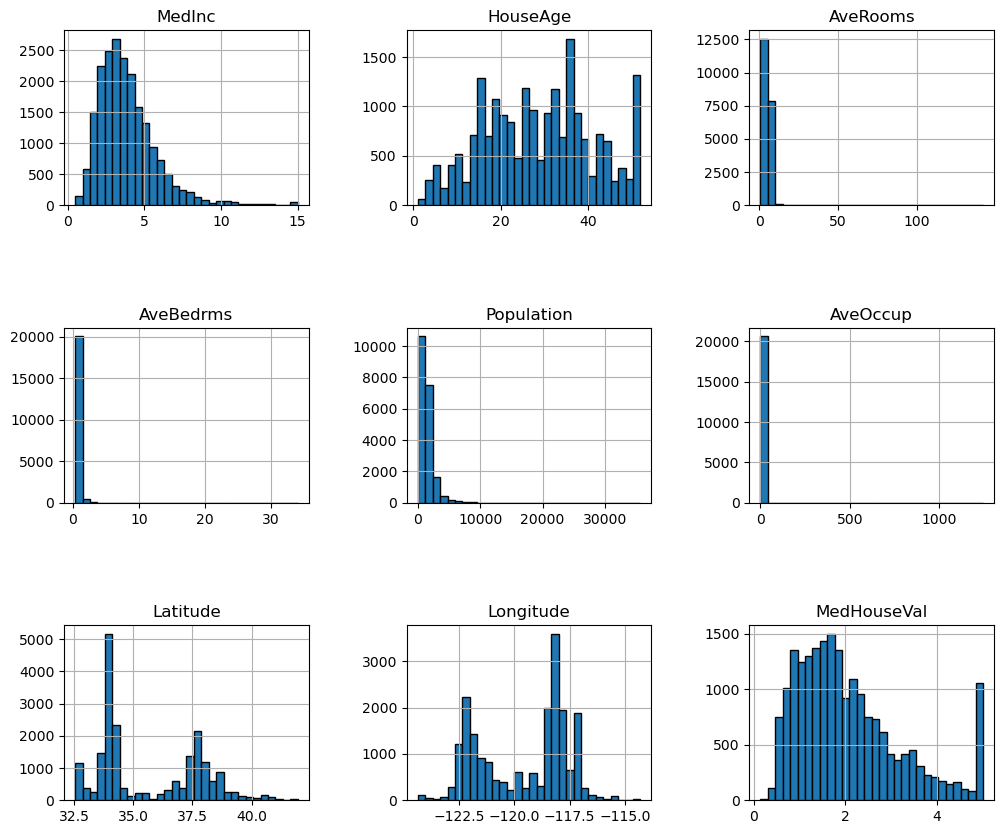

In [3]:
# EDA

housing.hist(figsize = (12, 10), bins = 30, edgecolor = 'black')
plt.subplots_adjust(hspace = 0.7, wspace = 0.4)

In [4]:
features_of_interest = ["AveRooms", "AveBedrms", "AveOccup", "Population"]
housing[features_of_interest].describe()

,AveRooms,AveBedrms,AveOccup,Population
count,20640.000000,20640.000000,20640.000000,20640.000000
mean,5.429000,1.096675,3.070655,1425.476744
std,2.474173,0.473911,10.386050,1132.462122
min,0.846154,0.333333,0.692308,3.000000
25%,4.440716,1.006079,2.429741,787.000000
50%,5.229129,1.048780,2.818116,1166.000000
75%,6.052381,1.099526,3.282261,1725.000000
max,141.909091,34.066667,1243.333333,35682.000000


### The MedInc and the MedHouseVal features appear to have a more or less normal distribution but with a long tail towards the right. All teh features are distributed at different scales. In HouseAge and HouseValue column values are capped at 50 and 5 respectively. The distribution of HouseAge seems to be pretty uniform. 

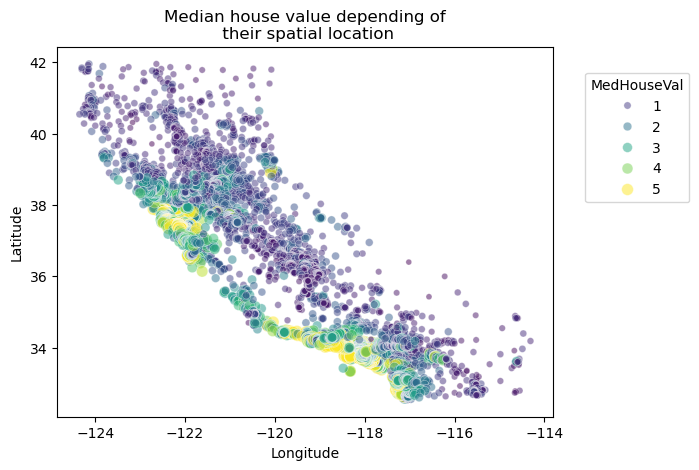

In [5]:
import seaborn as sns

sns.scatterplot(
    data=housing,
    x="Longitude",
    y="Latitude",
    size="MedHouseVal",
    hue="MedHouseVal",
    palette="viridis",
    alpha=0.5,
)
plt.legend(title="MedHouseVal", bbox_to_anchor=(1.05, 0.95), loc="upper left")
_ = plt.title("Median house value depending of\n their spatial location")

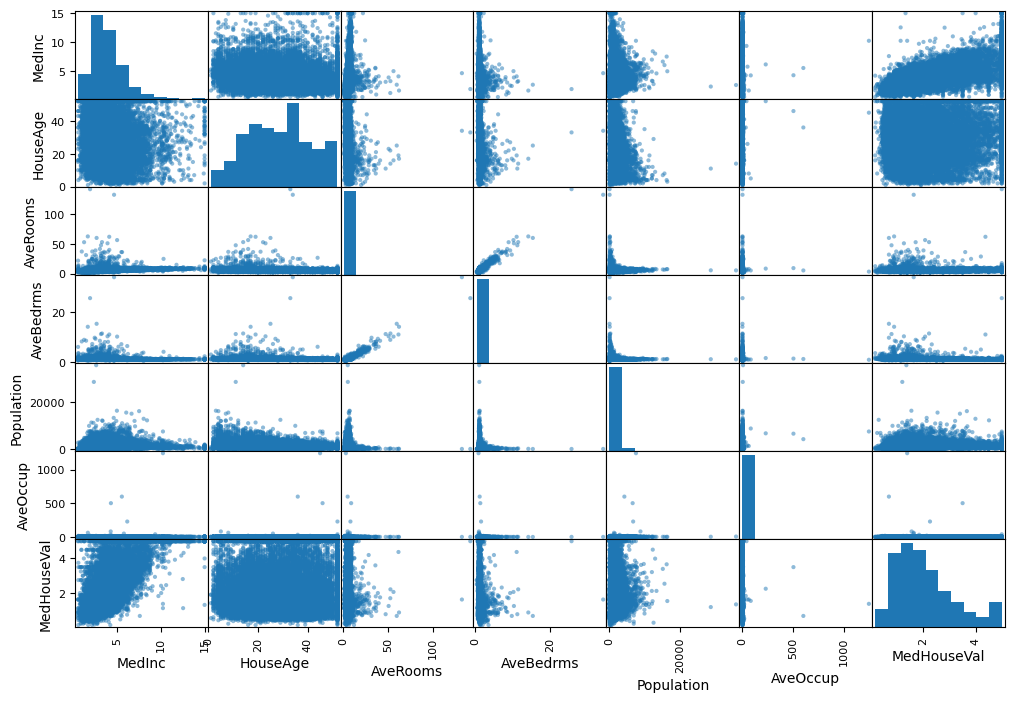

In [6]:
attributes = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup','MedHouseVal']
scatter_matrix(housing[attributes], figsize=(12,8))
plt.show()

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = housing.iloc[:, :-1]
y = housing.iloc[:, -1]

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]
print(vif_data)

      Feature         VIF
0      MedInc   11.511140
1    HouseAge    7.195917
2    AveRooms   45.993601
3   AveBedrms   43.590314
4  Population    2.935745
5    AveOccup    1.095243
6    Latitude  559.874071
7   Longitude  633.711654


### From the heatmaps and the VIFs, we can see that latitute and longitude are highly collinear, so are AveRooms and AveBedrms. MedInc seems to be the most highly correlated with the target based on the outputs in the heatmap

In [8]:
# split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# standard scaling
regression_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])


In [9]:
# fit the model and then predict
regression_pipeline.fit(X_train, y_train)
y_pred = regression_pipeline.predict(X_test)
print(f"R2 Score : ", r2_score(y_test, y_pred))
print(f"MSE : ", mean_squared_error(y_test, y_pred))
print(f"RMSE : ", root_mean_squared_error(y_test, y_pred))

R2 Score :  0.606182873268452
MSE :  0.5225705599807215
RMSE :  0.7228904204516211


In [10]:
regression_pipeline['regressor'].coef_

array([ 0.82631253,  0.11229344, -0.26268907,  0.30091188, -0.00761114,
       -0.04071124, -0.90280574, -0.87490724])

### The coefficients of some features like AvgRooms and AvgBedrooms seem to have a nullification effect. Both Longitude and Latitude both have very low coefficients suggesting that they are not important to the task. Multicollinearity prevents use from creating a robust model using classic regression techniques and hence we obtain inaccurate predictions, as is illustrated by the low R2 Score. 

Alpha = 0.1
MSE = 0.5195854464678509
RMSE = 0.7208227566245747
R2 = 0.6084325002406442

Alpha = 1
MSE = 0.5195872635650016
RMSE = 0.7208240170561755
R2 = 0.6084311308485779

Alpha = 10
MSE = 0.5196136889202422
RMSE = 0.7208423467862042
R2 = 0.608411216298715

Alpha = 100
MSE = 0.5205789432157161
RMSE = 0.7215115683173181
R2 = 0.6076837859719417



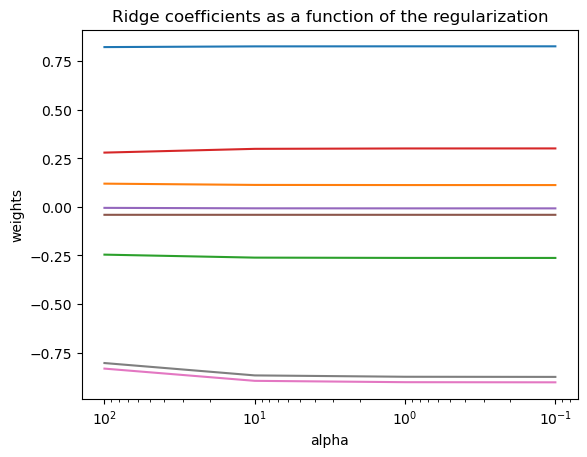

In [11]:
# Ridge Regression
from sklearn import linear_model

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

alphas = [0.1, 1, 10, 100]
ridge_coefs = []

for alpha in alphas:
    ridge = linear_model.Ridge(alpha = alpha)
    ridge.fit(X_train, y_train)
    ridge_coefs.append(ridge.coef_)
    y_pred = ridge.predict(X_test)
    print(f"Alpha = {alpha}")
    print(f"MSE = {mean_squared_error(y_test, y_pred)}")
    print(f"RMSE = {root_mean_squared_error(y_test, y_pred)}")
    print(f"R2 = {r2_score(y_test, y_pred)}\n")


ax = plt.gca()

ax.plot(alphas, ridge_coefs)
ax.set_xscale("log")
ax.set_xlim(ax.get_xlim()[::-1])  # reverse axis
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("Ridge coefficients as a function of the regularization")
plt.axis("tight")
plt.show()

Alpha = 0.1
MSE = 0.6807859615115104
RMSE = 0.8250975466643385
R2 = 0.48694933887678615

Alpha = 1
MSE = 1.3272414211431631
RMSE = 1.1520596430494225
R2 = -0.00022933357168031243

Alpha = 10
MSE = 1.3272414211431631
RMSE = 1.1520596430494225
R2 = -0.00022933357168031243

Alpha = 100
MSE = 1.3272414211431631
RMSE = 1.1520596430494225
R2 = -0.00022933357168031243



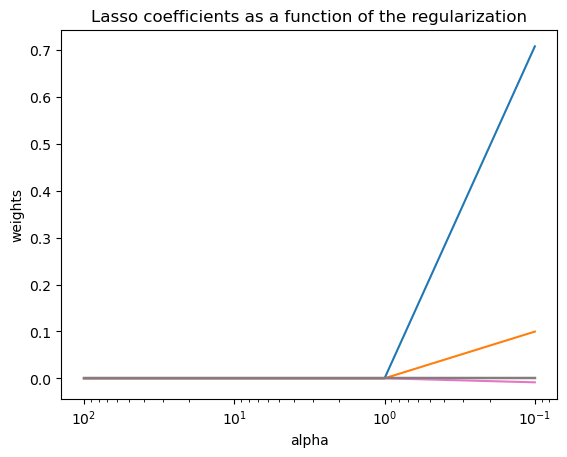

In [12]:
# Lasso Regression

alphas = [0.1, 1, 10, 100]
lasso_coefs = []

for alpha in alphas:
    lasso = linear_model.Lasso(alpha = alpha)
    lasso.fit(X_train, y_train)
    lasso_coefs.append(lasso.coef_)
    y_pred = lasso.predict(X_test)
    print(f"Alpha = {alpha}")
    print(f"MSE = {mean_squared_error(y_test, y_pred)}")
    print(f"RMSE = {root_mean_squared_error(y_test, y_pred)}")
    print(f"R2 = {r2_score(y_test, y_pred)}\n")


ax = plt.gca()
ax.plot(alphas, lasso_coefs)
ax.set_xscale("log")
ax.set_xlim(ax.get_xlim()[::-1])  # reverse axis
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("Lasso coefficients as a function of the regularization")
plt.axis("tight")
plt.show()

### Ridge Regression is more robust for this task compared to Lasso Regression which performs poorly for higher alpha values. Half of the features are eliminated but the performance is still poor. 

Ridge and Lasso both addressed multicollinearity by shrinking coefficients, making the model more stable. Ridge reduced the magnitude of highly correlated features, while Lasso eliminated 4 of the features entirely by setting them to zero. Ridge showed way better predictive accuracy than Lasso, but interestingly, it didn’t significantly outperform the standard Linear Regression. This suggests that multicollinearity may not have been severe enough to affect model performance dramatically, or the regularization strength wasn’t optimal. Ridge is preferred when all features contribute to the output and multicollinearity is present. Lasso is ideal for feature selection when we suspect many features are irrelevant. In high-dimensional datasets with many irrelevant features, Lasso would be more effective due to its ability to zero out coefficients. Regularization in general helps reduce overfitting by constraining the model complexity, making it more generalizable to unseen data.

## 2. Classification with SVMs (Breast Cancer Wisconsin)

Predicting malignant vs. benign diagnoses on the
[Breast Cancer Wisconsin](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic))
dataset, with a focus on an SVM implemented from scratch.

- **EDA & feature engineering:** target encoding, `StandardScaler` normalization, and polynomial /
  interaction features.
- **Models:** logistic regression and a decision tree (scikit-learn baselines) plus a **Support
  Vector Machine implemented from scratch** using the `cvxopt` quadratic-programming solver — with
  both **linear** ($K(x,x') = x^\top x'$) and **RBF** ($K(x,x') = \exp(-\gamma\lVert x-x'\rVert^2)$)
  kernels.
- **Evaluation & tuning:** accuracy, precision, recall, F1, confusion matrices, ROC-AUC, and
  hyperparameter tuning (`C`, tree depth, kernel / $\gamma$).

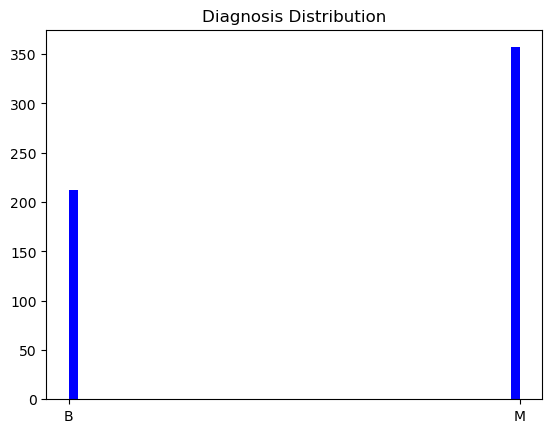

The distribution appears to be uniform
Numbe of missing values in the dataset :  mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
diagnosis                  0
dtype: int64
Correla

In [13]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns = data.feature_names)
df['diagnosis'] = np.where(data.target == 1, 'M', 'B')
df.head()

plt.hist(df['diagnosis'], bins = 50, color = 'blue')
plt.title('Diagnosis Distribution')
plt.show()

print("The distribution appears to be uniform")

print("Numbe of missing values in the dataset : ", df.isnull().sum())

# exploring relationships between columns
print('Correlation of mean radius wrt mean texture:', df['mean radius'].corr(df['mean texture']))
print('Correlation of mean texture wrt mean smoothness:', df['mean smoothness'].corr(df['mean texture']))
print('Correlation of mean smoothness wrt mean radius:', df['mean radius'].corr(df['mean smoothness']))

In [14]:
df.dtypes

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [15]:
# encoding the diagnosis column
df['diagnosis'] = df['diagnosis'].astype('category').cat.codes
df.head()

# normalize continuos features
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
scaler = MinMaxScaler()

for column in df.columns:
    
    if df[column].dtype != 'object':
        # print(column)
        df[column] = scaler.fit_transform(df[[column]])

# # split into features and target before adding polynomial features
# X = np.array(df.drop(columns=['diagnosis']))
# y = np.array(df['diagnosis'])
# # now use polynomial features
# print("Before : ", X.shape)

# poly = PolynomialFeatures(2)
# X = poly.fit_transform(X)
# print("After : ", X.shape)

features_to_expand = df[['mean radius', 'mean texture', 'mean concavity']]

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(features_to_expand)

feature_names = poly.get_feature_names_out(['mean radius', 'mean texture', 'mean concavity'])

poly_df = pd.DataFrame(poly_features, columns=feature_names)

df = pd.concat([df, poly_df], axis=1)

In [16]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'diagnosis', 'mean radius', 'mean texture', 'mean concavity',
       'mean radius^2', 'mean radius mean texture',
       'mean radius mean concavity', 'mean texture^2',
       'mean texture mean concavity', 'mean concavity^2'],
      dtype='object')

In [17]:
X = np.array(df.drop(columns=['diagnosis']))
y = np.array(df['diagnosis'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

# Decision Tree Classfier
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier()
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]

In [18]:
# SVM
from cvxopt import matrix, solvers

class SVM:
    def __init__(self, C=1.0, kernel = 'linear', gamma = 1.0):
        self.C = C
        self.kernel = kernel
        self.gamma = gamma

    def linear_kernel(self, x, y):
        return np.dot(x, y.T)

    def rbf_kernel(self, x, y):
        if x.ndim == 1:
            x = x[np.newaxis, :]
        if y.ndim == 1:
            y = y[np.newaxis, :]
        dists = np.linalg.norm(x[:, np.newaxis] - y, axis=2)**2
        return np.exp(-self.gamma * dists)
    
    def compute_kernel(self, X, Y):
        if self.kernel == 'linear':
            return self.linear_kernel(X, Y)
        elif self.kernel == 'rbf':
            return self.rbf_kernel(X, Y)
        else:
            raise ValueError("Unsupported kernel")

    def fit(self, X, y):
        n_samples, _ = X.shape
        y = y * 1.0
        y[y == 0] = -1  # convert to -1 and 1

        # K = np.dot(X, X.T)
        K = self.compute_kernel(X, X)

        P = matrix(np.outer(y, y) * K)
        q = matrix(-np.ones(n_samples))

        A = matrix(y.reshape(1, -1))
        b = matrix(0.0)

        G_std = np.diag(-np.ones(n_samples))
        h_std = np.zeros(n_samples)

        G_slack = np.identity(n_samples)
        h_slack = np.ones(n_samples) * self.C

        G = matrix(np.vstack((G_std, G_slack)))
        h = matrix(np.hstack((h_std, h_slack)))

        solvers.options['show_progress'] = False
        solution = solvers.qp(P, q, G, h, A, b)

        alpha = np.ravel(solution['x'])
        sv = alpha > 1e-5
        self.alpha = alpha[sv]
        self.sv_X = X[sv]
        self.sv_y = y[sv]

        self.w = np.dot((self.alpha * self.sv_y), self.sv_X)
        self.b = np.mean(self.sv_y - np.dot(self.sv_X, self.w))

    def project(self, X):
        return np.dot(X, self.w) + self.b

    def predict(self, X):
        return (self.project(X) >= 0).astype(int)

In [19]:
svm = SVM(C=1.0)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.project(X_test)


Logistic Regression Classification Report
              precision    recall  f1-score   support

         0.0       0.97      0.80      0.88        45
         1.0       0.88      0.99      0.93        69

    accuracy                           0.91       114
   macro avg       0.93      0.89      0.90       114
weighted avg       0.92      0.91      0.91       114

Confusion Matrix:


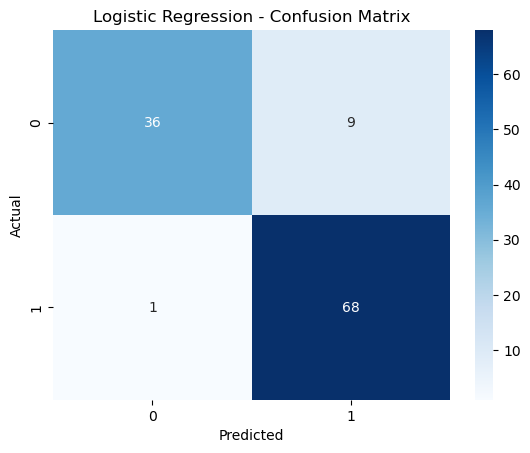


Decision Tree Classification Report
              precision    recall  f1-score   support

         0.0       0.85      0.87      0.86        45
         1.0       0.91      0.90      0.91        69

    accuracy                           0.89       114
   macro avg       0.88      0.88      0.88       114
weighted avg       0.89      0.89      0.89       114

Confusion Matrix:


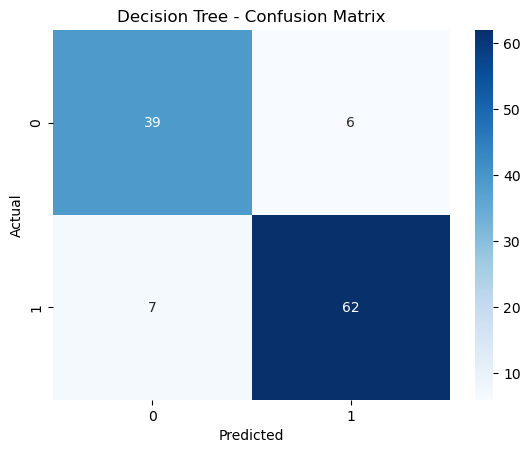


Custom SVM Classification Report
              precision    recall  f1-score   support

         0.0       1.00      0.89      0.94        45
         1.0       0.93      1.00      0.97        69

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:


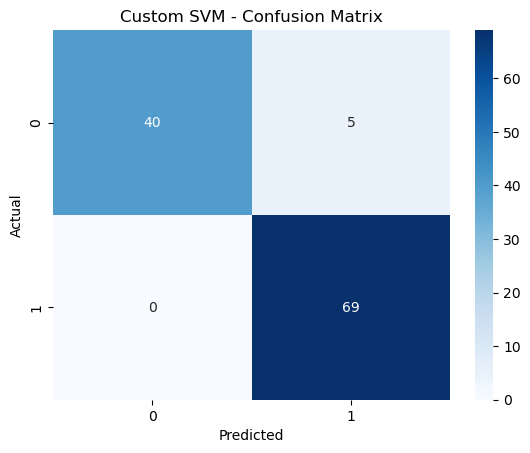

In [20]:
import seaborn as sns

def evaluate_model(y_test, y_pred, model_name):
    print(f"\n{model_name} Classification Report")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Evaluate all
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_svm, "Custom SVM")

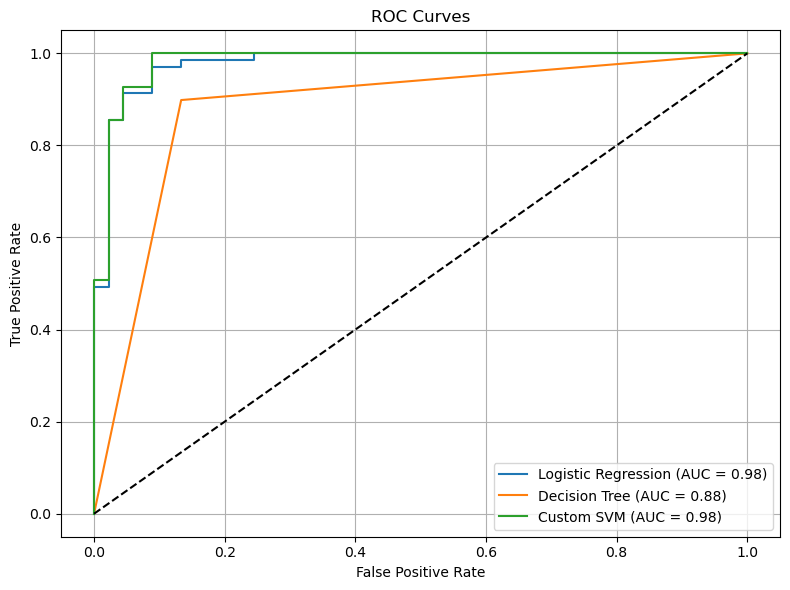

In [21]:
plt.figure(figsize=(8, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)
plt.plot(fpr_svm, tpr_svm, label=f'Custom SVM (AUC = {auc_svm:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
# Task 3 - Hyper parameter tuning

from sklearn.model_selection import GridSearchCV

# Logistic Rgression Hyperparameter Tuning
params = {'C': [0.01, 0.1, 1, 10, 100]}
log_reg = LogisticRegression(max_iter=1000)
grid_lr = GridSearchCV(log_reg, params, cv=5, scoring='f1')
grid_lr.fit(X_train, y_train)

print("Best Logistic Regression C:", grid_lr.best_params_)

# Decision Tree Hyperparameter tuning
params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 5, 10]
}
tree = DecisionTreeClassifier()
grid_dt = GridSearchCV(tree, params, cv=5, scoring='f1')
grid_dt.fit(X_train, y_train)

print("Best Decision Tree Params:", grid_dt.best_params_)
best_dt = grid_dt.best_estimator_
best_lr = grid_lr.best_estimator_


# SVM 
svm_linear = SVM(C=1.0, kernel='linear')
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

svm_rbf = SVM(C=1.0, kernel='rbf', gamma=0.5)
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

Best Logistic Regression C: {'C': 10}
Best Decision Tree Params: {'max_depth': None, 'min_samples_leaf': 1}



Logistic Regression Classification Report
              precision    recall  f1-score   support

         0.0       1.00      0.87      0.93        45
         1.0       0.92      1.00      0.96        69

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114

Confusion Matrix:


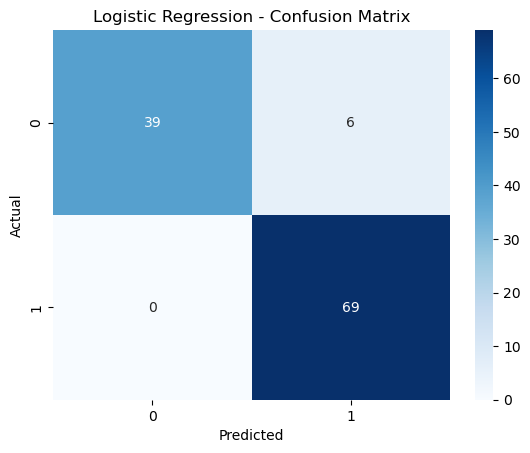


Decision Tree Classification Report
              precision    recall  f1-score   support

         0.0       0.87      0.91      0.89        45
         1.0       0.94      0.91      0.93        69

    accuracy                           0.91       114
   macro avg       0.91      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114

Confusion Matrix:


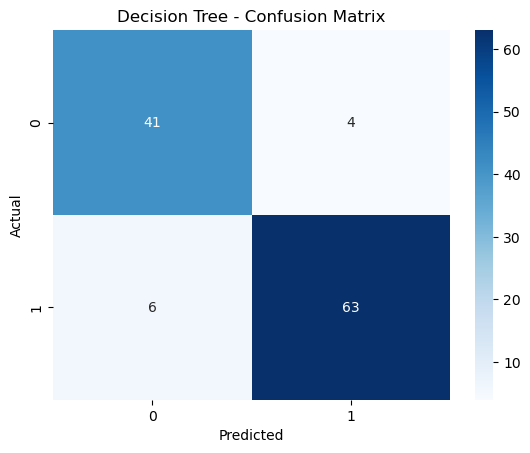


SVM Linear Kernel Classification Report
              precision    recall  f1-score   support

         0.0       1.00      0.89      0.94        45
         1.0       0.93      1.00      0.97        69

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:


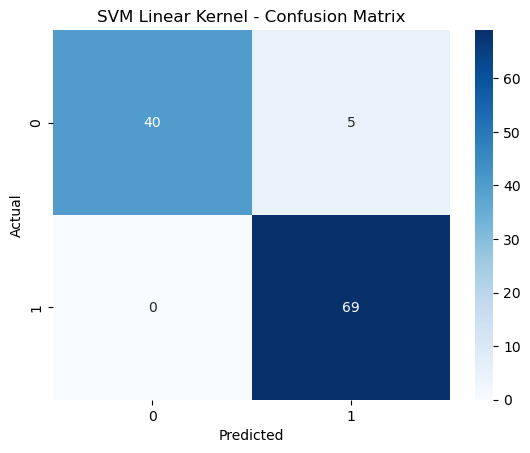


SVM RBF Kernel Classification Report
              precision    recall  f1-score   support

         0.0       1.00      0.82      0.90        45
         1.0       0.90      1.00      0.95        69

    accuracy                           0.93       114
   macro avg       0.95      0.91      0.92       114
weighted avg       0.94      0.93      0.93       114

Confusion Matrix:


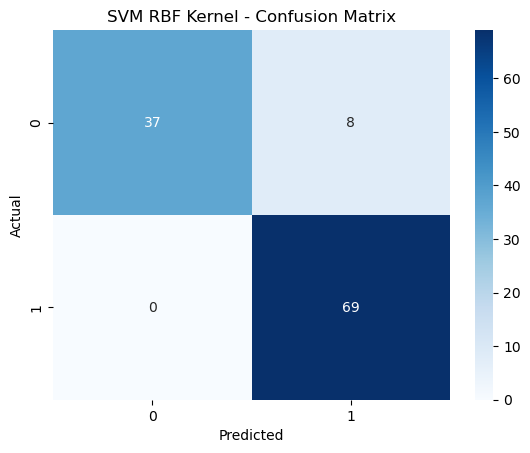

In [23]:
# evaluate the tuned models

y_pred_lr_tuned = best_lr.predict(X_test)
y_prob_lr_tuned = best_lr.predict_proba(X_test)[:, 1]

y_pred_dt_tuned = best_dt.predict(X_test)
y_prob_dt_tuned = best_dt.predict_proba(X_test)[:, 1]

y_pred_svm_linear = svm_linear.predict(X_test)
y_prob_svm_linear = svm_linear.project(X_test)

y_pred_svm_rbf = svm_rbf.predict(X_test)
y_prob_svm_rbf = svm_rbf.project(X_test)


evaluate_model(y_test, y_pred_lr_tuned, "Logistic Regression")
evaluate_model(y_test, y_pred_dt_tuned, "Decision Tree")
evaluate_model(y_test, y_pred_svm_linear, "SVM Linear Kernel")
evaluate_model(y_test, y_pred_svm_rbf, "SVM RBF Kernel")

### Model comparison & discussion

**Best model.** The SVM with an RBF kernel performed best overall. The linear-kernel SVM was the
most stable across folds — its linear nature resists the overfitting that models like the decision
tree are prone to.

**Kernel choice.** The RBF kernel consistently beat the linear kernel, especially when the data was
not linearly separable, by capturing non-linear decision boundaries — at the cost of more careful
tuning of $\gamma$ and $C$.

**Scaling & polynomial features.** Both mattered. Feature scaling is critical for SVMs (the
distance-based RBF kernel is sensitive to feature magnitude). Polynomial features let the linear
kernel capture non-linear patterns, but increased dimensionality and overfitting risk.

**Real-world implications.** False negatives here mean a missed diagnosis and disease progression, so
**recall** should be prioritized over precision — missing a cancer case is far more costly than a
false alarm resolved by further testing. As-is, the from-scratch SVM is not clinic-ready: it scales
poorly to large data, offers no calibrated probabilities, and is sensitive to kernel and
hyperparameter choices.

## 3. K-Means Clustering from Scratch (Wholesale Customers)

Implementing K-Means from scratch (no scikit-learn) plus a framework that evaluates multiple cluster
counts, applied to the UCI **Wholesale Customers** dataset for customer segmentation (Channel and
Region columns dropped; spending features only).

- **EDA & preprocessing:** feature distributions and standardization.
- **From-scratch K-Means:** random centroid initialization, Euclidean assignment, centroid
  recomputation, and convergence.
- **Model selection:** runs candidate cluster counts (e.g. 2–6), computing **WCSS** and **silhouette
  score** to choose the best $k$, with an asymptotic runtime analysis of $O(n \cdot k \cdot i)$.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Fresh             440 non-null    int64
 1   Milk              440 non-null    int64
 2   Grocery           440 non-null    int64
 3   Frozen            440 non-null    int64
 4   Detergents_Paper  440 non-null    int64
 5   Delicassen        440 non-null    int64
dtypes: int64(6)
memory usage: 20.8 KB
None
               Fresh          Milk       Grocery        Frozen  \
count     440.000000    440.000000    440.000000    440.000000   
mean    12000.297727   5796.265909   7951.277273   3071.931818   
std     12647.328865   7380.377175   9503.162829   4854.673333   
min         3.000000     55.000000      3.000000     25.000000   
25%      3127.750000   1533.000000   2153.000000    742.250000   
50%      8504.000000   3627.000000   4755.500000   1526.000000   
75%     16933.750000   7190.25

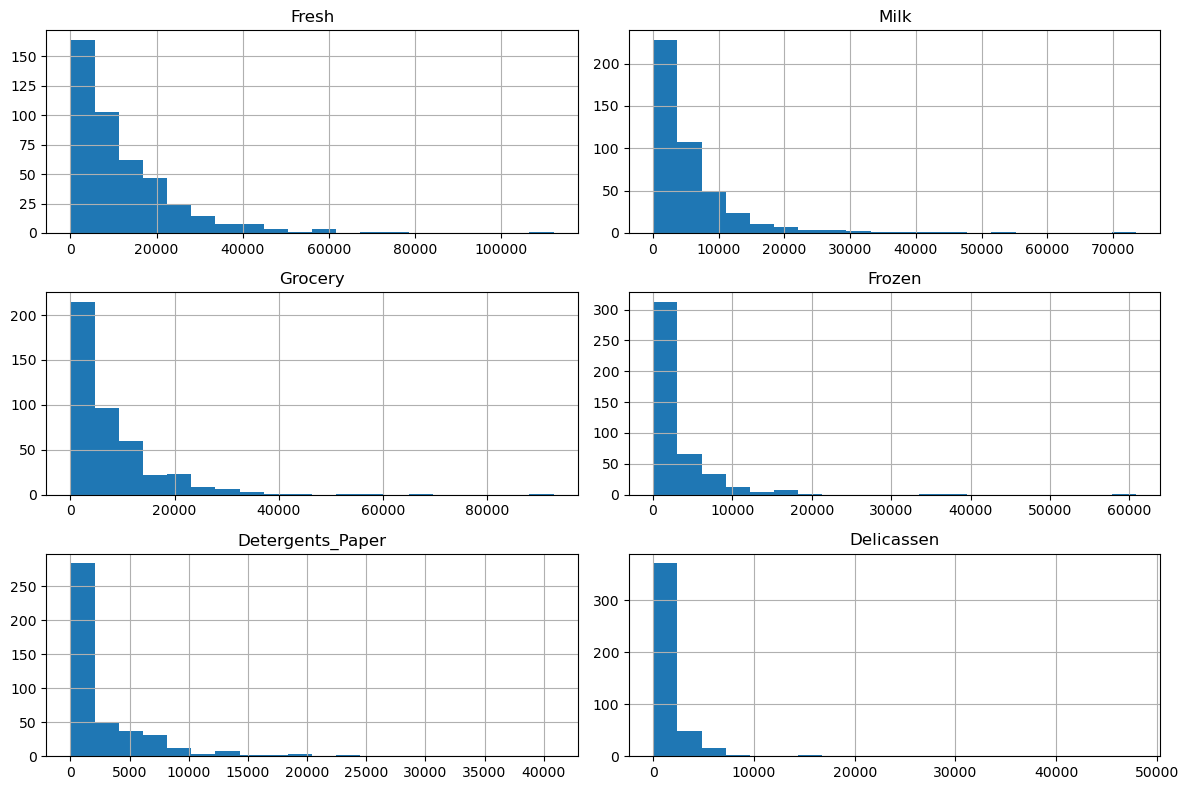

In [25]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import time

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
df = pd.read_csv(url)

# Drop Channel and Region columns
df_clean = df.drop(columns=['Channel', 'Region'])

# EDA
print(df_clean.info())
print(df_clean.describe())
print("Missing values:\n", df_clean.isnull().sum())

# Distribution of features
df_clean.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(df_clean)


Objective - Customers in the Wholesale Customers dataset are clustered based on their spending patterns, allowing for focused marketing and strategic decision-making.  The emphasis is on combining comparable purchasing behaviors into six product groups.

Algorithm Overview:
     1. Randomly pick k data points as initial centroids.
     2. Assign each point to the nearest centroid using Euclidean distance.
     3. Recompute centroids as the mean of points in each cluster.
     4. Repeat steps 2–3 until convergence or a set number of iterations.

Considerations:
    1. Data is numeric and standardized. Random initialization is used.
    2. Sensitive to initialization and outliers.
    3. Assumes spherical, equally sized clusters.

In [26]:
# Helper functions for KMeans
def initialize_centroids(X, k):
    indices = np.random.choice(X.shape[0], k, replace=False)
    return X[indices]

def compute_distances(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return distances

def assign_clusters(distances):
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k):
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

def compute_wcss(X, labels, centroids):
    return sum(np.sum((X[labels == i] - centroids[i])**2) for i in range(len(centroids)))


In [27]:
def custom_kmeans(X, k, max_iters=100, tol=1e-4):
    centroids = initialize_centroids(X, k)
    for i in range(max_iters):
        old_centroids = centroids.copy()
        distances = compute_distances(X, centroids)
        labels = assign_clusters(distances)
        centroids = update_centroids(X, labels, k)

        if np.allclose(old_centroids, centroids, atol=tol):
            break
    wcss = compute_wcss(X, labels, centroids)
    return labels, centroids, wcss


In [28]:
candidate_k = [2, 3, 4, 5, 6]
results = []

for k in candidate_k:
    start = time.time()
    labels, centroids, wcss = custom_kmeans(X, k)
    sil_score = silhouette_score(X, labels)
    end = time.time()
    results.append({
        'k': k,
        'WCSS': wcss,
        'Silhouette Score': sil_score,
        'Runtime (s)': end - start
    })
    print(f"k={k}, WCSS={wcss:.2f}, Silhouette={sil_score:.4f}, Runtime={end - start:.2f}s")


k=2, WCSS=1954.18, Silhouette=0.5909, Runtime=0.01s
k=3, WCSS=1642.43, Silhouette=0.4563, Runtime=0.01s
k=4, WCSS=1352.78, Silhouette=0.3568, Runtime=0.01s
k=5, WCSS=1085.59, Silhouette=0.3516, Runtime=0.01s
k=6, WCSS=1196.60, Silhouette=0.2421, Runtime=0.01s


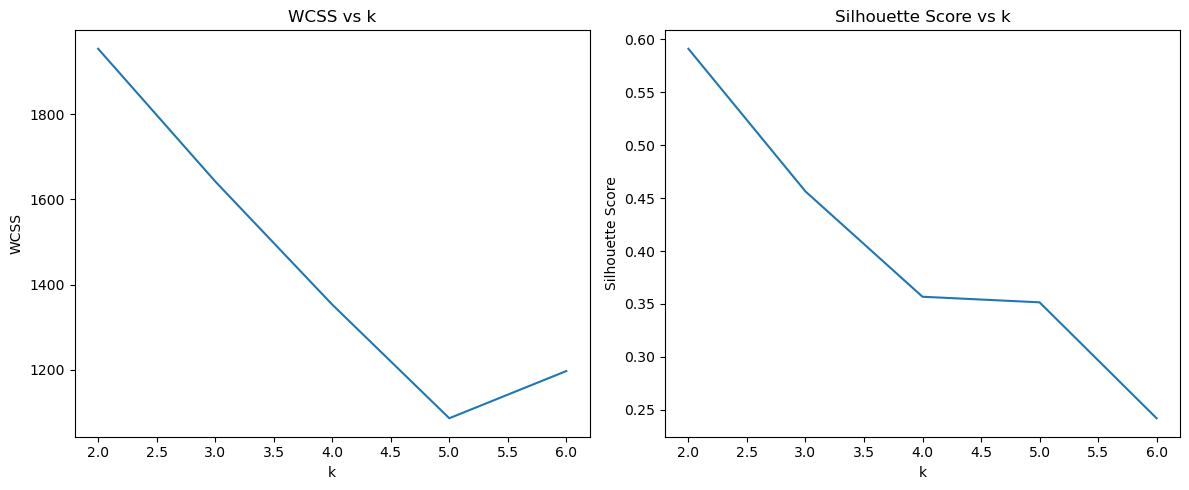

   k         WCSS  Silhouette Score  Runtime (s)
0  2  1954.183565          0.590904     0.011897
1  3  1642.432933          0.456267     0.009851
2  4  1352.780639          0.356834     0.008882
3  5  1085.586604          0.351567     0.007860
4  6  1196.598955          0.242129     0.012715


In [29]:
results_df = pd.DataFrame(results)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(data=results_df, x='k', y='WCSS', ax=ax[0]).set(title='WCSS vs k')
sns.lineplot(data=results_df, x='k', y='Silhouette Score', ax=ax[1]).set(title='Silhouette Score vs k')
plt.tight_layout()
plt.show()

print(results_df)


In [30]:
# Complexity: O(n × k × i) where:
# n = X.shape[0], k = number of clusters, i = iterations until convergence
n, d = X.shape
print(f"Asymptotic Complexity: O(n * k * i) → For n={n}, d={d}, i ~ 100 max")

# Optional: View cluster centroids for best k
best_k = results_df.sort_values(by='Silhouette Score', ascending=False).iloc[0]['k']
print(f"Best number of clusters: {int(best_k)}")

# Rerun with best k and analyze centroids
labels, centroids, _ = custom_kmeans(X, int(best_k))
df_clean['Cluster'] = labels
cluster_summary = df_clean.groupby('Cluster').mean()
display(cluster_summary)


Asymptotic Complexity: O(n * k * i) → For n=440, d=6, i ~ 100 max
Best number of clusters: 2


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,11189.698113,19090.264151,26911.396226,4202.169811,11850.471698,3564.433962
1,12111.310078,3975.640827,5354.671835,2917.144703,1653.183463,1245.550388


The best overall performance was obtained using 5 clusters. The elbow method is commonly used to choose the best value of k and in the plots shown above, we can see that the left curve hits a minimum at k = 5 and then proceeds to increase, suggesting 5 clusters is optimal. 

### Cluster interpretation

Real world Interpretation:

    C1: High Fresh and Frozen - (Restaurants)
    C2: High Grocery and Detergents - (retail stores)
    C3: Low Spenders - small businesses
    C4: High across all - bulk (Costco)
    C5: Moderate Spenders

Applications:

    Marketing - Personalize offers by cluster, 
    Logistics - Predict demand for each segment,
    Sales Strategy - Focus efforts on high-spending clusters

Trade-offs:

    More clusters = better detail, longer runtime,
    Need balance between interpretability and accuracy